Importing Libraries

In [125]:
import matplotlib.pyplot as plt
import pandas as pd
import re

In [126]:
from collections import Counter

CSV TO DATAFRAME


In [127]:



df = pd.read_csv("data/similarityRelatedFeatures.csv")

print(df.head())
print(df.columns)
print(df.shape)
print(df.info())
print("Categories:", df["category"].nunique())
    

           category     brand                           price  \
0  wireless earbuds    Fhumsh  $19.97 with 92 percent savings   
1  wireless earbuds    Fhumsh  $19.97 with 92 percent savings   
2  wireless earbuds  XIAOWTEK  $19.99 with 90 percent savings   
3  wireless earbuds    TRAUSI  $20.99 with 92 percent savings   
4  wireless earbuds  HAOYUYAN  $23.98 with 92 percent savings   

                                         description  \
0  About this itemSmart LED Display & 50H Sport H...   
1  About this itemErgonomic Wireless Earbuds for ...   
2  About this itemLED Power Display and 50H Playb...   
3  About this item【Instant Pairing & Seamless Con...   
4  About this item【Sports Comfort & IPX7 Waterpro...   

                                               title  
0  Wireless Earbuds, Bluetooth 5.3 Headphones HiF...  
1  Wireless Earbuds, Bluetooth 5.3 Headphones HiF...  
2  XIAOWTEK Wireless Earbuds, 2026 Bluetooth 5.4 ...  
3  Wireless Earbuds Bluetooth Headphones, 54H Pla...

Data Cleaning


In [128]:

df["description"] = df["description"].fillna("")

df["price"] = (
    df["price"]
    .str.extract(r"\$([\d,]+(?:\.\d+)?)")[0]
    .str.replace(",", "", regex=False)
    .astype(float)
)



df.info()

<class 'pandas.DataFrame'>
RangeIndex: 832 entries, 0 to 831
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   category     832 non-null    str    
 1   brand        671 non-null    str    
 2   price        708 non-null    float64
 3   description  832 non-null    str    
 4   title        832 non-null    str    
dtypes: float64(1), str(4)
memory usage: 32.6 KB


In [129]:
print("Brands:", df["brand"].nunique())
print("Categories:", df["category"].nunique())

Brands: 295
Categories: 28


In [130]:
df.groupby("category")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
DSLR camera,11.0,357.808182,214.444197,79.99,219.9900,287.990,514.0000,756.96
USB-C hub,13.0,25.019231,12.944249,7.98,16.9900,19.990,39.9600,44.95
air purifier,4.0,96.365000,65.224452,22.49,65.6150,91.490,122.2400,179.99
backpack,14.0,38.297857,26.217330,13.99,26.9900,29.990,36.8725,94.99
bluetooth speaker,12.0,87.009167,112.175796,9.99,18.4900,30.990,85.6525,329.99
budget laptop,10.0,273.533000,120.136082,79.99,224.9500,245.745,314.7400,544.99
candle,42.0,27.856667,20.848026,9.99,17.2300,19.990,25.9900,119.98
coffee maker,35.0,97.651429,111.153681,21.99,42.4900,74.950,99.9900,555.95
desk lamp LED,47.0,31.354043,17.749009,9.99,19.9900,25.490,41.4700,79.99


In [131]:
df.groupby("category")["price"].transform(
    lambda x: pd.qcut(
        x,
        q=3,
        labels=["Low Budget", "Mid Budget", "High Budget"]
    )
)

0       Low Budget
1       Low Budget
2       Mid Budget
3       Mid Budget
4      High Budget
          ...     
827     Low Budget
828            NaN
829     Low Budget
830     Low Budget
831     Low Budget
Name: price, Length: 832, dtype: category
Categories (3, str): ['Low Budget' < 'Mid Budget' < 'High Budget']

In [132]:
df.duplicated().sum()
df = df.drop_duplicates()
df.info()


<class 'pandas.DataFrame'>
Index: 745 entries, 0 to 830
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   category     745 non-null    str    
 1   brand        599 non-null    str    
 2   price        634 non-null    float64
 3   description  745 non-null    str    
 4   title        745 non-null    str    
dtypes: float64(1), str(4)
memory usage: 34.9 KB


Standardizing the texts

In [133]:


def clean_text(text):
    if pd.isna(text):
        return ""
    
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    
    return text.strip()

df["title"] = df["title"].apply(clean_text)
df["description"] = df["description"].apply(clean_text)
df["brand"] = df["brand"].apply(clean_text)
df["category"] = df["category"].apply(clean_text)

In [134]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df["price"] = scaler.fit_transform(
    df[["price"]]
)

In [135]:
df.info()

<class 'pandas.DataFrame'>
Index: 745 entries, 0 to 830
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   category     745 non-null    str    
 1   brand        745 non-null    str    
 2   price        634 non-null    float64
 3   description  745 non-null    str    
 4   title        745 non-null    str    
dtypes: float64(1), str(4)
memory usage: 34.9 KB


In [136]:
df["price"].head()

0    0.015041
1    0.015041
2    0.015059
3    0.015934
4    0.018552
Name: price, dtype: float64

In [137]:
df.shape
df.head()
df.info()
df.describe(include="all")

<class 'pandas.DataFrame'>
Index: 745 entries, 0 to 830
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   category     745 non-null    str    
 1   brand        745 non-null    str    
 2   price        634 non-null    float64
 3   description  745 non-null    str    
 4   title        745 non-null    str    
dtypes: float64(1), str(4)
memory usage: 34.9 KB


,category,brand,price,description,title
count,745,745,634.000000,745,745
unique,28,296,NaN,595,720
top,desk lamp led,,NaN,,reebok power fury athletic sneakers for women ...
freq,48,146,NaN,126,4
mean,NaN,NaN,0.060955,NaN,NaN
std,NaN,NaN,0.098137,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN
25%,NaN,NaN,0.012432,NaN,NaN
50%,NaN,NaN,0.023813,NaN,NaN
75%,NaN,NaN,0.067588,NaN,NaN


EXPLORATORY DATA ANALYSIS


In [138]:
df[df["title"].duplicated(keep=False)].sort_values("title")

,category,brand,price,description,title
400,gaming chair,jecqcupg,0.067588,about this item 7 point precision support tota...,gaming chair for adults gamer game ergonomic p...
403,gaming chair,jecqcupg,NaN,about this item 7 point precision support tota...,gaming chair for adults gamer game ergonomic p...
419,gaming chair,jecqcupg,0.093853,about this item 7 point precision support tota...,gaming chair for adults gamer game ergonomic p...
538,t shirt,,0.006671,,gildan adult ultra cotton t shirt style g2000 ...
542,t shirt,,0.010243,,gildan adult ultra cotton t shirt style g2000 ...
550,t shirt,,0.008974,,gildan adult ultra cotton t shirt style g2000 ...
528,t shirt,,NaN,,gildan men s crew t shirts multipack style g1100
532,t shirt,,0.015934,,gildan men s crew t shirts multipack style g1100
570,t shirt,,0.017685,,gildan men s v neck t shirts multipack style g...
558,t shirt,,0.015059,,gildan men s v neck t shirts multipack style g...


In [139]:
df["brand"].value_counts().head(20)

brand
                    146
oral b               18
philips sonicare     17
gtplayer             13
instant pot          11
razer                10
yankee candle        10
logitech              9
keurig                9
astercook             8
levoit                7
ninja                 7
cuisinart             7
sojos                 7
samsung               6
otterbox              6
canon                 6
owala                 6
paperage              6
skechers              6
Name: count, dtype: int64

In [140]:
df[df["brand"].str.strip() == ""].shape

(146, 5)

###146 items has no brand value


In [141]:
df["price"].describe()

count    634.000000
mean       0.060955
std        0.098137
min        0.000000
25%        0.012432
50%        0.023813
75%        0.067588
max        1.000000
Name: price, dtype: float64

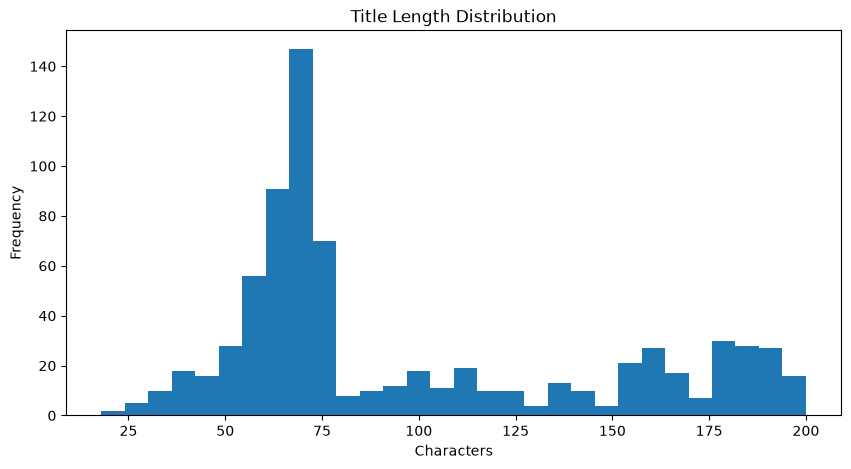

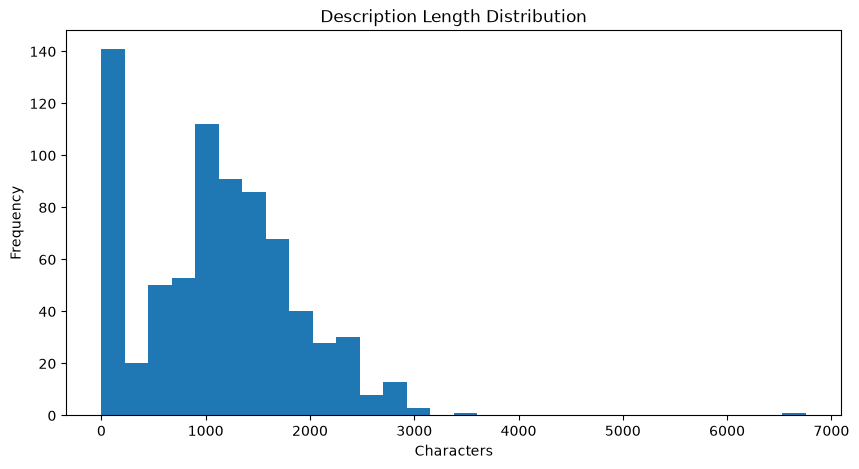

In [142]:
df["title_length"] = df["title"].str.len()
df["description_length"] = df["description"].str.len()

df[["title_length", "description_length"]].describe()

df["title_length"].plot(kind="hist", bins=30, figsize=(10, 5))
plt.title("Title Length Distribution")
plt.xlabel("Characters")
plt.show()

df["description_length"].plot(kind="hist", bins=30, figsize=(10, 5))
plt.title("Description Length Distribution")
plt.xlabel("Characters")
plt.show()

In [143]:
df["title_word_count"] = df["title"].str.split().str.len()
df["description_word_count"] = df["description"].str.split().str.len()

df[["title_word_count", "description_word_count"]].describe()

,title_word_count,description_word_count
count,745.000000,745.000000
mean,16.310067,184.802685
std,8.218077,128.996780
min,3.000000,0.000000
25%,10.000000,93.000000
50%,12.000000,188.000000
75%,23.000000,265.000000
max,39.000000,1197.000000


In [144]:
(df["description"].str.strip() == "").sum()

np.int64(126)

In [145]:
df.info()

<class 'pandas.DataFrame'>
Index: 745 entries, 0 to 830
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   category                745 non-null    str    
 1   brand                   745 non-null    str    
 2   price                   634 non-null    float64
 3   description             745 non-null    str    
 4   title                   745 non-null    str    
 5   title_length            745 non-null    int64  
 6   description_length      745 non-null    int64  
 7   title_word_count        745 non-null    int64  
 8   description_word_count  745 non-null    int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 58.2 KB


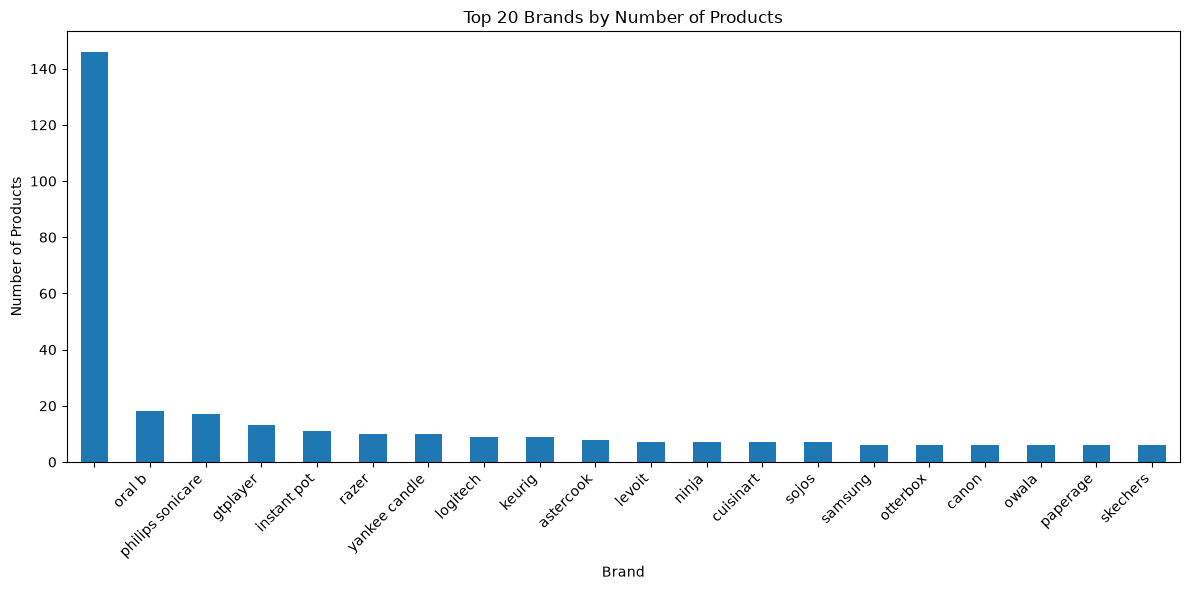

In [146]:


brand_counts = df["brand"].value_counts().head(20)

brand_counts.plot(kind="bar", figsize=(12, 6))

plt.title("Top 20 Brands by Number of Products")
plt.xlabel("Brand")
plt.ylabel("Number of Products")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [147]:
words = " ".join(df["title"]).lower().split()

Counter(words).most_common(20)

[('for', 338),
 ('with', 263),
 ('black', 174),
 ('men', 104),
 ('5', 99),
 ('women', 97),
 ('chair', 94),
 ('3', 91),
 ('and', 89),
 ('gaming', 86),
 ('2', 83),
 ('in', 82),
 ('desk', 78),
 ('1', 77),
 ('lamp', 73),
 ('set', 71),
 ('s', 69),
 ('home', 68),
 ('usb', 67),
 ('steel', 67)]

In [148]:
words = " ".join(df["description"]).lower().split()

Counter(words).most_common(20)

[('and', 4734),
 ('the', 3717),
 ('to', 2880),
 ('for', 2814),
 ('a', 2642),
 ('with', 2284),
 ('your', 1628),
 ('this', 1382),
 ('you', 1323),
 ('in', 1294),
 ('of', 1238),
 ('more', 1044),
 ('or', 1044),
 ('is', 935),
 ('it', 871),
 ('about', 682),
 ('on', 630),
 ('up', 604),
 ('product', 601),
 ('details', 579)]

TF-IDF

In [149]:
from sklearn.feature_extraction.text import TfidfVectorizer

title_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2)
)

description_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2)
)

title_vectors = title_vectorizer.fit_transform(df["title"])
description_vectors = description_vectorizer.fit_transform(df["description"])

In [150]:
def brand_similarity(query_brand, product_brand):
    if not query_brand or not product_brand:
        return 0.0

    query_brand = query_brand.lower().strip()
    product_brand = product_brand.lower().strip()

    if query_brand == product_brand:
        return 1.0

    return 0.0

In [151]:
brands = (
    df["brand"]
    .unique()
    .tolist()
)

brands = [
    brand
    for brand in brands
    if brand
]

In [152]:
def find_brand(query, brands):
    query = query.lower()

    for brand in brands:
        if brand in query:
            return brand

    return None

In [153]:
query = "wireless gaming mouse"

query_title_vector = title_vectorizer.transform([query])
query_description_vector = description_vectorizer.transform([query])

query_brand = find_brand(query, brands)

title_scores = cosine_similarity(
    query_title_vector,
    title_vectors
)[0]

description_scores = cosine_similarity(
    query_description_vector,
    description_vectors
)[0]

final_scores = []

for i in range(len(df)):

    product_brand = df.iloc[i]["brand"]

    
    brand_score = brand_similarity(
        query_brand,
        product_brand
    )

    
    if query_brand:

        final_score = (
            0.60 * title_scores[i] +
            0.30 * description_scores[i] +
            0.10 * brand_score
        )

    else:

        final_score = (
            0.70 * title_scores[i] +
            0.30 * description_scores[i]
        )

    final_scores.append(final_score)

df["similarity_score"] = final_scores

In [154]:


recommendations = df.sort_values(
    "similarity_score",
    ascending=False
).head(10)

print(
    recommendations[
        ["title", "brand", "category", "similarity_score"]
    ]
)

                                                title       brand  \
17  logitech g pro x2 superstrike wireless gaming ...  logitech g   
19  razer basilisk v3 x hyperspeed customizable wi...       razer   
21  inphic a9 v2 explorer wireless gaming mouse 12...      inphic   
24  aula sc620 wireless gaming mouse tri mode 2 4g...    strikonx   
28  razer orochi v2 wireless gaming mouse 950 hr b...       razer   
26  logitech g502 x plus wireless rgb gaming mouse...  logitech g   
20  redragon m602 gaming mouse ergonomic rgb gamin...    redragon   
23  attack shark x3 49g ultra lightweight wireless...  manbasnake   
31  redragon wireless gaming mouse tri mode 2 4g b...    redragon   
22  razer viper v3 hyperspeed wireless pc gaming m...       razer   

        category  similarity_score  
17  gaming mouse          0.396945  
19  gaming mouse          0.352014  
21  gaming mouse          0.342214  
24  gaming mouse          0.340085  
28  gaming mouse          0.303817  
26  gaming mouse  

Evaluation

In [155]:
evaluation_queries = [
    "wireless gaming mouse",
    "wireless earbuds",
    "desk lamp",
    "electric toothbrush",
    "Razer gaming mouse",
    "Nike sneakers",
    "coffee maker"
]

In [156]:
for query in evaluation_queries:

    results = recommend_products(query, top_n=10)

    print("\nQUERY:", query)

    print(
        results[
            ["title", "brand", "category", "similarity_score"]
        ].to_string(index=False)
    )

NameError: name 'recommend_products' is not defined